In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (891, 15)


In [5]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
missing_percent = df.isnull().mean() * 100

print("Missing values percentage:")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

Missing values percentage:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


In [7]:
# Drop deck because most of its values are missing
df = df.drop(columns=["deck"])

# Fill missing age values with the median
df["age"] = df["age"].fillna(df["age"].median())

# Drop rows where embarked or embark_town is missing
df = df.dropna(subset=["embarked", "embark_town"])

print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape after cleaning: (889, 14)

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [8]:
df.to_csv("titanic.csv", index=False)

print("Cleaned Titanic dataset saved successfully!")

Cleaned Titanic dataset saved successfully!


In [9]:
print("Dataset shape:", df.shape)

print("\nDescriptive statistics:")
print(df.describe())

Dataset shape: (889, 14)

Descriptive statistics:
         survived      pclass         age       sibsp       parch        fare
count  889.000000  889.000000  889.000000  889.000000  889.000000  889.000000
mean     0.382452    2.311586   29.315152    0.524184    0.382452   32.096681
std      0.486260    0.834700   12.984932    1.103705    0.806761   49.697504
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.895800
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   35.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


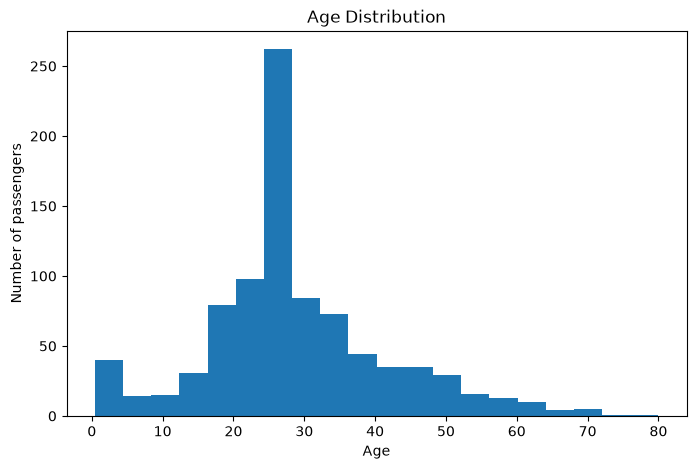

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.title("Age Distribution")
plt.show()

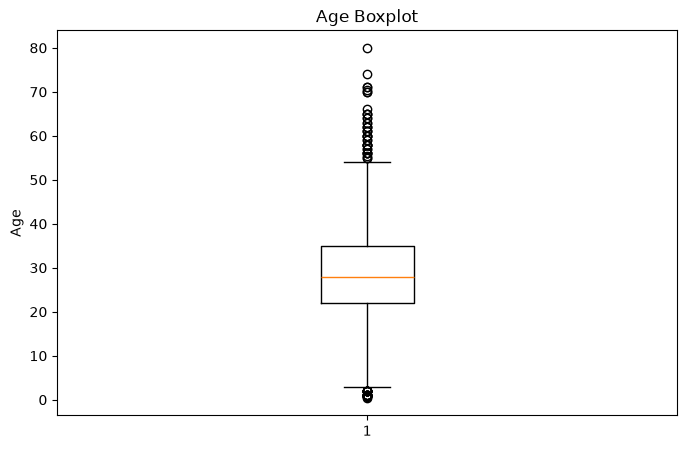

In [11]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["age"])
plt.ylabel("Age")
plt.title("Age Boxplot")
plt.show()

In [15]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

age_outliers = df[
    (df["age"] < lower_limit) |
    (df["age"] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of age outliers:", len(age_outliers))

Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower limit: 2.5
Upper limit: 54.5
Number of age outliers: 65


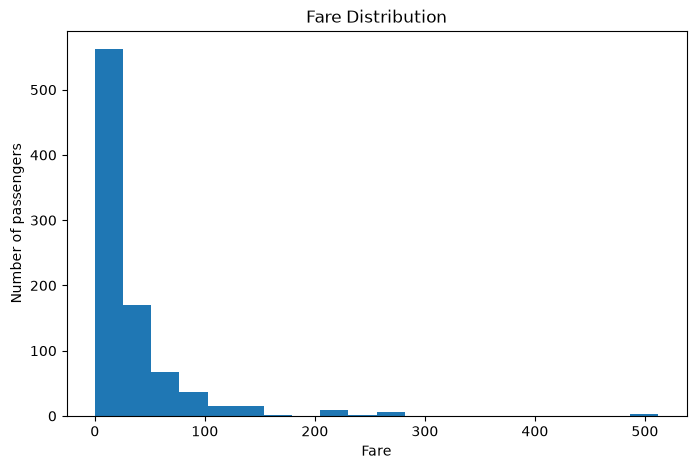

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["fare"], bins=20)
plt.xlabel("Fare")
plt.ylabel("Number of passengers")
plt.title("Fare Distribution")
plt.show()

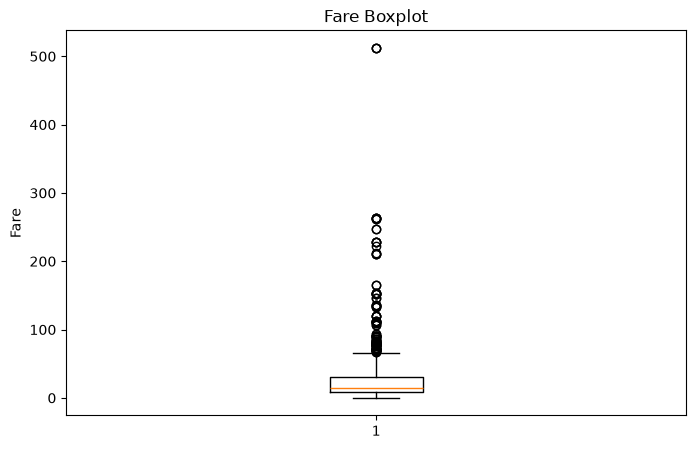

In [17]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["fare"])
plt.ylabel("Fare")
plt.title("Fare Boxplot")
plt.show()

In [18]:
Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)

IQR_fare = Q3_fare - Q1_fare

lower_limit_fare = Q1_fare - 1.5 * IQR_fare
upper_limit_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df["fare"] < lower_limit_fare) |
    (df["fare"] > upper_limit_fare)
]

print("Q1:", Q1_fare)
print("Q3:", Q3_fare)
print("IQR:", IQR_fare)
print("Lower limit:", lower_limit_fare)
print("Upper limit:", upper_limit_fare)
print("Number of fare outliers:", len(fare_outliers))

Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower limit: -26.7605
Upper limit: 65.6563
Number of fare outliers: 114


In [19]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare mean:", fare_mean)
print("Fare median:", fare_median)
print("Fare mode:", fare_mode)

Fare mean: 32.09668087739032
Fare median: 14.4542
Fare mode: 8.05


In [20]:
fare_skewness = df["fare"].skew()

print("Fare skewness:", fare_skewness)

Fare skewness: 4.801440211044194


In [21]:
survival_by_sex = df.groupby("sex")["survived"].mean()

print("Survival rate by sex:")
print(survival_by_sex)

Survival rate by sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64


In [22]:
survival_by_class = df.groupby("pclass")["survived"].mean()

print("Survival rate by passenger class:")
print(survival_by_class)

Survival rate by passenger class:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [23]:
survival_by_sex_class = df.groupby(["sex", "pclass"])["survived"].mean()

print("Survival rate by sex and passenger class:")
print(survival_by_sex_class)

Survival rate by sex and passenger class:
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


In [24]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]

corr_matrix = df[corr_cols].corr()

print("Correlation matrix:")
print(corr_matrix)

Correlation matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


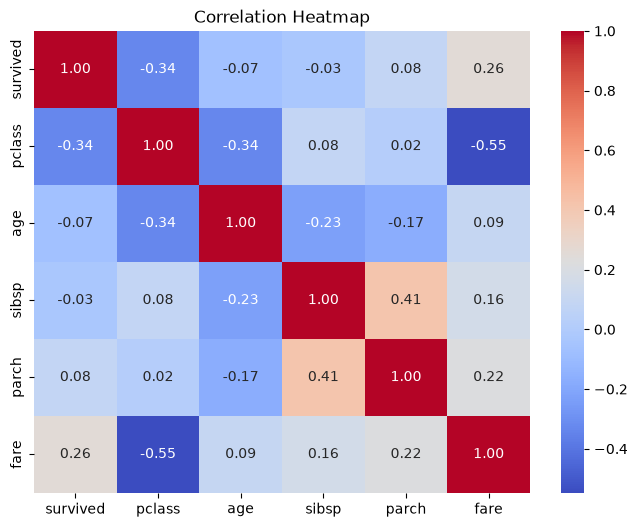

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Correlation Interpretation:
The strongest correlation is between pclass and fare with a correlation of -0.5482, indicating a moderate negative relationship. The second strongest is between pclass and age with a correlation of -0.3365, indicating a weaker negative relationship. Correlation shows the strength and direction of a linear relationship, but it does not imply causation.


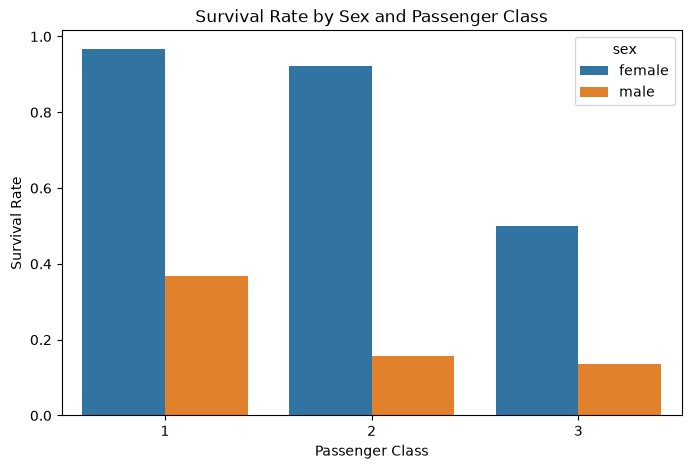

In [26]:
survival_plot = df.groupby(["sex", "pclass"])["survived"].mean().reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=survival_plot,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Sex and Passenger Class")
plt.show()

Survival Rate by Sex and Passenger Class

Survival rates were higher for females than males across all passenger classes. First-class passengers also had higher survival rates than passengers in lower classes. The combination of sex and passenger class shows a clear difference in survival outcomes

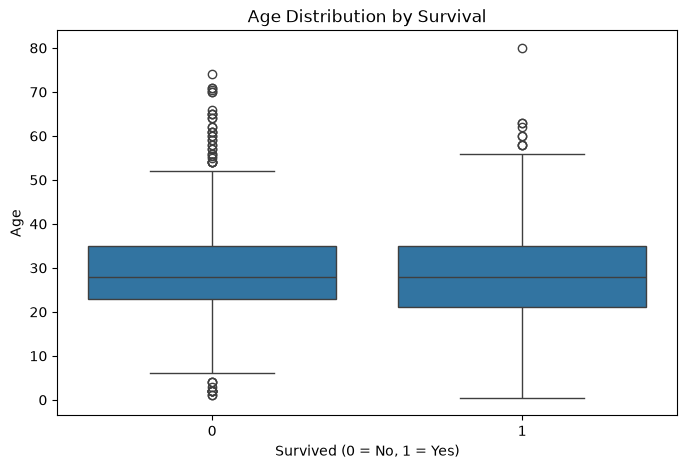

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.title("Age Distribution by Survival")
plt.show()

Age Distribution by Survival

The age distributions of survivors and non-survivors show differences across the passenger population. Younger passengers were represented among survivors, while non-survivors were spread across a wider age range. The plot also shows some variation and outliers in passenger ages.

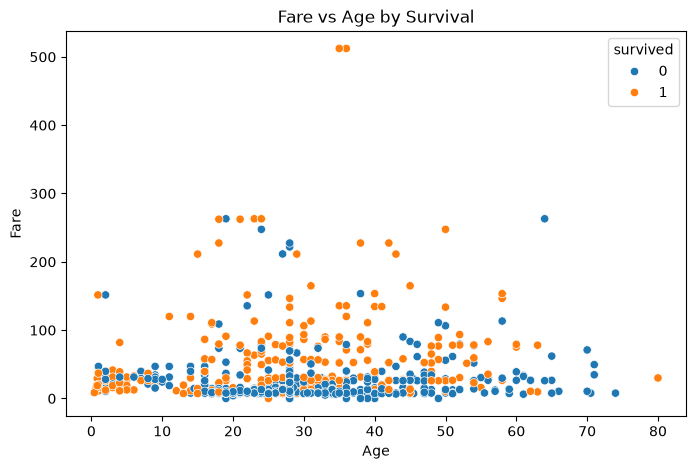

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived"
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Fare vs Age by Survival")
plt.show()

Fare vs. Age by Survival

The scatter plot shows the relationship between passenger age and fare while separating passengers by survival status. Higher fares are generally associated with passengers from higher passenger classes, and survival outcomes appear across different age and fare ranges. The plot also shows several observations with unusually high fares.

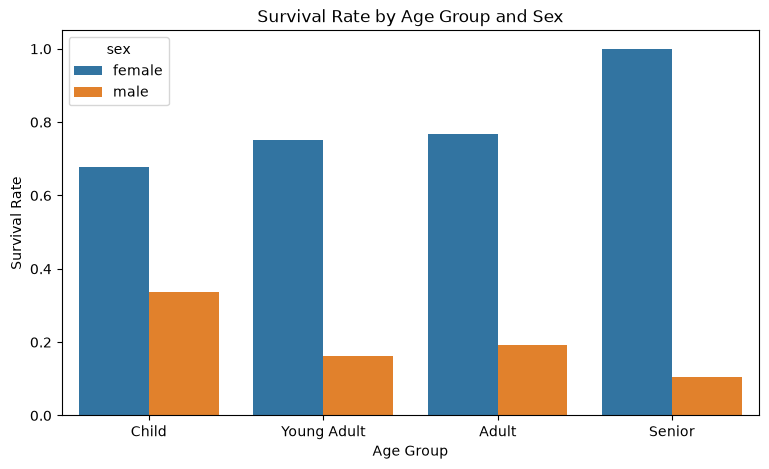

In [29]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 35, 60, 100],
    labels=["Child", "Young Adult", "Adult", "Senior"]
)

age_sex_survival = (
    df.groupby(["age_group", "sex"], observed=True)["survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_sex_survival,
    x="age_group",
    y="survived",
    hue="sex"
)

plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Age Group and Sex")
plt.show()

Survival Rate by Age Group and Sex

Survival rates varied across age groups and between males and females. Female passengers generally had higher survival rates than male passengers within the age groups shown. The comparison highlights the combined effect of age group and sex on observed survival rates.

In [30]:
df.to_csv("titanic.csv", index=False)

print("Final Titanic dataset saved!")
print("Shape:", df.shape)

Final Titanic dataset saved!
Shape: (889, 15)


EDA Summary
The cleaned dataset contains 889 passengers and 15 columns.
deck was removed because 77.22% of its values were missing, while missing age values were filled using the median.
The overall survival rate was approximately 38.25%.
Survival rates differed substantially by sex and passenger class.
The fare distribution was strongly right-skewed, with a skewness of approximately 4.80.
The IQR method identified 65 age outliers and 114 fare outliers.
The strongest correlation among the selected numerical variables was between passenger class and fare (-0.5482).

In [31]:
from sklearn.preprocessing import StandardScaler

standardized_df = df[["age", "fare"]].copy()

print("Before Standardization:")
print(standardized_df.agg(["mean", "std"]))

scaler = StandardScaler()

standardized_df[["age", "fare"]] = scaler.fit_transform(
    standardized_df[["age", "fare"]]
)

print("\nAfter Standardization:")
print(standardized_df.agg(["mean", "std"]))

Before Standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After Standardization:
               age          fare
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00
